# Importando dados!

In [257]:
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd 
dados = pd.read_csv('dados/Customer-Churn.csv')
dados.head()

,Maior65Anos,Conjuge,Dependentes,MesesDeContrato,TelefoneFixo,VariasLinhasTelefonicas,ServicoDeInternet,SegurancaOnline,BackupOnline,SeguroNoDispositivo,SuporteTecnico,TVaCabo,StreamingDeFilmes,TipoDeContrato,PagamentoOnline,FormaDePagamento,ContaMensal,Churn
0,0,Sim,Nao,1,Nao,SemServicoTelefonico,DSL,Nao,Sim,Nao,Nao,Nao,Nao,Mensalmente,Sim,ChequeDigital,29.85,Nao
1,0,Nao,Nao,34,Sim,Nao,DSL,Sim,Nao,Sim,Nao,Nao,Nao,UmAno,Nao,ChequePapel,56.95,Nao
2,0,Nao,Nao,2,Sim,Nao,DSL,Sim,Sim,Nao,Nao,Nao,Nao,Mensalmente,Sim,ChequePapel,53.85,Sim
3,0,Nao,Nao,45,Nao,SemServicoTelefonico,DSL,Sim,Nao,Sim,Sim,Nao,Nao,UmAno,Nao,DebitoEmConta,42.30,Nao
4,0,Nao,Nao,2,Sim,Nao,FibraOptica,Nao,Nao,Nao,Nao,Nao,Nao,Mensalmente,Sim,ChequeDigital,70.70,Sim


## Organizando tabela para a analise

In [258]:
troca = {
    'Sim': 1,
    'Nao': 0
}
dadosmodificados = dados[['Conjuge', 'Dependentes', 'TelefoneFixo', 'PagamentoOnline', 'Churn']].replace(troca)
dadosmodificados.head()

,Conjuge,Dependentes,TelefoneFixo,PagamentoOnline,Churn
0,1,0,0,1,0
1,0,0,1,0,0
2,0,0,1,1,1
3,0,0,0,0,0
4,0,0,1,1,1


In [259]:
#transformação pelo get_dummies
dummie_dados = pd.get_dummies(dados.drop(['Conjuge', 'Dependentes', 'TelefoneFixo', 'PagamentoOnline', 'Churn'],
                axis=1))

#junção dos dados trasformados
dados_final = pd.concat([dadosmodificados, dummie_dados], axis=1)

In [260]:
dados_final.head()

,Conjuge,Dependentes,TelefoneFixo,PagamentoOnline,Churn,Maior65Anos,MesesDeContrato,ContaMensal,VariasLinhasTelefonicas_Nao,VariasLinhasTelefonicas_SemServicoTelefonico,...,StreamingDeFilmes_Nao,StreamingDeFilmes_SemServicoDeInternet,StreamingDeFilmes_Sim,TipoDeContrato_DoisAnos,TipoDeContrato_Mensalmente,TipoDeContrato_UmAno,FormaDePagamento_CartaoDeCredito,FormaDePagamento_ChequeDigital,FormaDePagamento_ChequePapel,FormaDePagamento_DebitoEmConta
0,1,0,0,1,0,0,1,29.85,0,1,...,1,0,0,0,1,0,0,1,0,0
1,0,0,1,0,0,0,34,56.95,1,0,...,1,0,0,0,0,1,0,0,1,0
2,0,0,1,1,1,0,2,53.85,1,0,...,1,0,0,0,1,0,0,0,1,0
3,0,0,0,0,0,0,45,42.30,0,1,...,1,0,0,0,0,1,0,0,0,1
4,0,0,1,1,1,0,2,70.70,1,0,...,1,0,0,0,1,0,0,1,0,0


## Possiveis perda de Clientes!!

In [261]:
dados_final.Churn.mode()

0    0
Name: Churn, dtype: int64

In [262]:
x = dados_final.drop(['Churn'], axis = 1) # Treina todos menos o churn 
y = dados_final['Churn'] # Testar 

In [263]:
from sklearn.model_selection import train_test_split

treino_x, teste_x, treino_y, teste_y = train_test_split(x, y, test_size= 0.25, random_state=22)

print('temos %d modoles para treinar e temos %d modelos para testar' % (len(treino_x), len(teste_x)))

temos 5282 modoles para treinar e temos 1761 modelos para testar


In [264]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_score



knn = KNeighborsClassifier(metric='euclidean')

knn.fit(treino_x, treino_y) # Treinou 

previsoes = knn.predict(teste_x) # prever 

print('Valor %.2f%%' % (precision_score(teste_y, previsoes) * 100))


Valor 57.73%


# Analise Grafica 

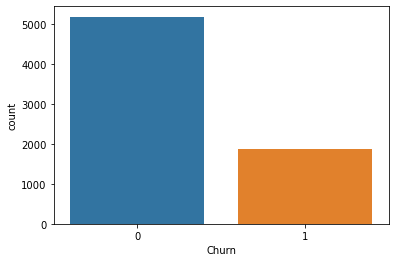

In [265]:
ax = sns.countplot(x='Churn', data=dados_final)

# Percentual das pessoas que continuaram com a assinatura

In [266]:
from scipy import stats

percentual =  stats.percentileofscore(dados_final.Churn, 0, kind = 'weak')
print('{0:.2f}% das pessoas continuaram na empresa'.format(percentual))

73.46% das pessoas continuaram na empresa


In [267]:
from sklearn.tree import DecisionTreeClassifier

modelo = DecisionTreeClassifier(max_depth = 2)

modelo.fit(treino_x, treino_y)

previsoes = modelo.predict(teste_x)

print( '%.2f%%' % (precision_score(teste_y, previsoes) * 100))

51.27%


In [268]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_validate

modelo = DecisionTreeClassifier(max_depth = 2)

results = cross_validate(modelo, x, y, cv = 3, return_train_score = False)
                                                 # removeu o treino
media = results['test_score'].mean()

desvio_padrao = results['test_score'].std()

print('Está entre [%.2f, %.2f]' % ((media - 2 * desvio_padrao) *100, (media + 2 * desvio_padrao)*100))

Está entre [75.28, 77.21]
